# EcoSort — Treino do zero (dataset só da câmera do projeto)

Este notebook treina um modelo de classificação **do zero**, usando **apenas as fotos tiradas com a câmera do projeto** (sem Kaggle).

"Do zero" aqui = partir do backbone pré-treinado `yolov8n-cls.pt` (igual aos seus notebooks originais) e **não** continuar dos modelos v5/v6.

> ⚠️ Importante sobre o crop: como suas fotos **já foram salvas recortadas** (crop central de 60%), o teste da seção 5 classifica a imagem como ela está, **sem recortar de novo**. Assim treino, teste e produção veem a mesma coisa.

## 1 - Conectar com o Drive e instalar dependências

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install split-folders ultralytics

print("\u2705 Pronto.")

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 85.6 MB/s eta 0:00:00
✅ Pronto.


## 2 - Apontar o dataset e conferir as classes

Coloque seu dataset no Drive com **uma subpasta por classe** (ex.: `cardboard/`, `metal/`, `plastic/`...), cada uma com as fotos daquela classe.

Esta célula copia o dataset para a sessão do Colab (não mexe no original do Drive) e mostra quantas imagens há por classe — confira se está minimamente equilibrado.

In [ ]:
import os, shutil

# 📂 AJUSTE AQUI: pasta no Drive com seu dataset (subpasta por classe)
DATASET_DRIVE = '/content/drive/MyDrive/EcoSort_Datasets/dataset-ecosort'

# Cópia local de trabalho (preserva o original do Drive)
DATASET_LOCAL = '/content/dataset-ecosort'

if not os.path.isdir(DATASET_DRIVE):
    raise FileNotFoundError(
        f"Não encontrei '{DATASET_DRIVE}'.\n"
        "Crie essa pasta no Drive com uma subpasta por classe e coloque as fotos dentro."
    )

# já está dividido em train/val? então usamos direto
ja_dividido = os.path.isdir(os.path.join(DATASET_DRIVE, 'train'))

if os.path.exists(DATASET_LOCAL):
    shutil.rmtree(DATASET_LOCAL)
shutil.copytree(DATASET_DRIVE, DATASET_LOCAL)
print(f"Dataset copiado para {DATASET_LOCAL}\n")

# Relatório de classes e contagem
pasta_para_contar = os.path.join(DATASET_LOCAL, 'train') if ja_dividido else DATASET_LOCAL
classes = sorted(
    d for d in os.listdir(pasta_para_contar)
    if os.path.isdir(os.path.join(pasta_para_contar, d)) and not d.startswith('.')
)

print(f"Classes encontradas ({len(classes)}):")
total = 0
contagens = {}
for c in classes:
    arqs = [f for f in os.listdir(os.path.join(pasta_para_contar, c)) if not f.startswith('.')]
    contagens[c] = len(arqs)
    total += len(arqs)
    print(f"   {c}: {len(arqs)} imagens")
print(f"\nTotal: {total} imagens")

# Avisos úteis
poucas = [c for c, n in contagens.items() if n < 20]
if poucas:
    print(f"\n\u26a0\ufe0f Classes com MENOS de 20 fotos (modelo pode ir mal nelas): {poucas}")
if contagens:
    mx, mn = max(contagens.values()), min(contagens.values())
    if mn > 0 and mx / mn >= 3:
        print(f"\u26a0\ufe0f Desequilíbrio grande entre classes (maior/menor = {mx/mn:.1f}x). "
              "Considere tirar mais fotos das classes pequenas ou usar o teto da seção 3.")

Dataset copiado para /content/dataset-ecosort

Classes encontradas (4):
   metal: 80 imagens
   paper: 190 imagens
   plastic: 60 imagens
   white-glass: 10 imagens

Total: 340 imagens

⚠️ Classes com MENOS de 20 fotos (modelo pode ir mal nelas): ['white-glass']
⚠️ Desequilíbrio grande entre classes (maior/menor = 19.0x). Considere tirar mais fotos das classes pequenas ou usar o teto da seção 3.


## 3 - (Opcional) Aumento leve das imagens

Com dataset pequeno, gerar algumas variações ajuda — mas de forma **moderada**, já que o YOLO também aumenta no treino. As fotos já estão recortadas, então a rotação é pequena de propósito (não cortar o objeto).

Deixe `AUGMENTAR = False` se quiser treinar só com as fotos originais. Pule esta célula inteira se o dataset já estiver dividido em `train/val`.

In [ ]:
import os, random
import numpy as np
import cv2
from PIL import Image, ImageEnhance

AUGMENTAR = True
NUM_COPIAS = 8           # variações por foto (moderado)
MAX_POR_CLASSE = 400    # ex.: 400 para limitar classes dominantes; None = sem teto

if ja_dividido:
    print("Dataset já está dividido em train/val — pulando aumento offline.")
elif not AUGMENTAR:
    print("AUGMENTAR=False — usando apenas as fotos originais.")
else:
    def augmentar(img):
        img = img.convert('RGB')
        if random.choice([True, False]):
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
        img = img.rotate(random.randint(-15, 15), expand=False)   # rotação pequena
        img = ImageEnhance.Brightness(img).enhance(random.uniform(0.6, 1.4))
        arr = np.array(img)
        if random.random() < 0.3:
            arr = cv2.GaussianBlur(arr, (5, 5), 0)
        if random.random() < 0.3:
            ruido = np.random.normal(0, 10, arr.shape)
            arr = np.clip(arr + ruido, 0, 255).astype(np.uint8)
        return Image.fromarray(arr)

    print("\U0001F9EC Gerando variações...\n")
    for c in classes:
        pasta = os.path.join(DATASET_LOCAL, c)
        originais = [f for f in os.listdir(pasta)
                     if not f.startswith('.') and not f.startswith('aug_')]
        for nome in originais:
            try:
                base = Image.open(os.path.join(pasta, nome))
                for i in range(NUM_COPIAS):
                    augmentar(base).save(os.path.join(pasta, f"aug_{i}_{nome}.jpg"), 'JPEG')
            except Exception as e:
                print(f"   \u274c erro em {c}/{nome}: {e}")
        # teto opcional por classe
        if MAX_POR_CLASSE is not None:
            arqs = [f for f in os.listdir(pasta) if not f.startswith('.')]
            if len(arqs) > MAX_POR_CLASSE:
                random.seed(42)
                manter = set(random.sample(arqs, MAX_POR_CLASSE))
                for f in arqs:
                    if f not in manter:
                        os.remove(os.path.join(pasta, f))
        total_c = len([f for f in os.listdir(pasta) if not f.startswith('.')])
        print(f"   {c}: {total_c} imagens após aumento")

    print("\n\u2705 Aumento concluído.")

🧬 Gerando variações...

   metal: 400 imagens após aumento
   paper: 400 imagens após aumento
   plastic: 400 imagens após aumento
   white-glass: 90 imagens após aumento

✅ Aumento concluído.


## 4 - Treinamento do zero

Divide em treino/validação (se ainda não estiver dividido) e treina partindo do `yolov8n-cls.pt`. Como é treino do zero (não fine-tuning), usamos o learning rate padrão e mais épocas.

> Se notar overfitting (acurácia de treino alta e validação baixa), uma opção é congelar camadas: adicione `freeze=10` no `train`.

In [ ]:
import os
import splitfolders
from ultralytics import YOLO

DATASET_LOCAL = '/content/dataset-ecosort'
pasta_pronta = '/content/dataset-ecosort-split'

if ja_dividido:
    pasta_pronta = DATASET_LOCAL
    print("Usando a divisão train/val que já veio no dataset.")
else:
    print("\u23F3 Dividindo em treino/validação (80/20)...")
    splitfolders.ratio(DATASET_LOCAL, output=pasta_pronta, seed=42, ratio=(0.8, 0.2))
    print(f"\u2705 Dataset pronto em: {pasta_pronta}")

# Treino do zero (parte do backbone pré-treinado, NÃO dos modelos v5/v6)
model = YOLO('yolov8n-cls.pt')

print("\n\U0001F680 Iniciando treinamento do zero...")
model.train(
    data=pasta_pronta,
    epochs=100,
    patience=20,
    imgsz=224,
    device=0,
    project='/content/drive/MyDrive/EcoSort_Modelos',
    name='modelo_camera_v1',
    # augmentation
    # scale=0.5,          # zoom/crop moderado
    erasing=0.2,
    hsv_v=0.4,
    hsv_s=0.3,
    fliplr=0.5,
)
print("\n\u2705 Treino concluído. Pesos em .../modelo_camera_v1/weights/best.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
⏳ Dividindo em treino/validação (80/20)...


Copying files: 1290 files [00:00, 7522.63 files/s]

✅ Dataset pronto em: /content/dataset-ecosort-split



🚀 Iniciando treinamento do zero...
Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset-ecosort-split, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.2, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.3, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=modelo_camera_v1, nbs

## 5 - Testar o modelo (sem recortar de novo + limiar)

Suas fotos já estão recortadas, então aqui **não** aplicamos crop — classificamos a imagem como ela está, igual ao que acontece na lixeira. O limiar continua: em classificação o modelo sempre devolve uma classe, então é o `if` que dá o "inconclusivo".

Faça o upload de uma imagem (já recortada, como sai da câmera):


Saving 10693278-m.jpg to 10693278-m.jpg

--- RESULTADO ---
Classe: PAPER  |  Certeza: 99.96%
{
  "lixeira_id": "smart_bin_01",
  "timestamp": "2026-06-26T12:28:19.981787+00:00",
  "detection": {
    "class_name": "paper",
    "confidence": 0.9996
  }
}


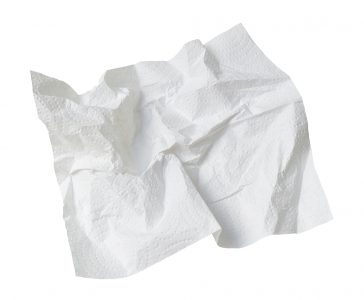

In [ ]:
from ultralytics import YOLO
from google.colab import files
from PIL import Image
import IPython.display as display
import json
from datetime import datetime, timezone

caminho_do_modelo = '/content/drive/MyDrive/EcoSort_Modelos/modelo_camera_v1/weights/best.pt'
LIMIAR = 0.75  # softmax é superconfiante; comece alto e ajuste

modelo_treinado = YOLO(caminho_do_modelo)

print("Faça o upload de uma imagem (já recortada, como sai da câmera):")
uploaded = files.upload()

for nome_arquivo in uploaded.keys():
    caminho_imagem = f"/content/{nome_arquivo}"
    img = Image.open(caminho_imagem).convert('RGB')

    # sem crop aqui: a foto já vem recortada da câmera
    resultados = modelo_treinado.predict(source=img, save=False, verbose=False)
    for resultado in resultados:
        idx = resultado.probs.top1
        nome_da_classe = resultado.names[idx]
        certeza = resultado.probs.top1conf.item()

        print("\n--- RESULTADO ---")
        if certeza >= LIMIAR:
            print(f"Classe: {nome_da_classe.upper()}  |  Certeza: {certeza*100:.2f}%")
            payload = {
                "lixeira_id": "smart_bin_01",
                "timestamp": datetime.now(timezone.utc).isoformat(),
                "detection": {"class_name": nome_da_classe, "confidence": round(certeza, 4)},
            }
            print(json.dumps(payload, indent=2))
        else:
            print(f"INCONCLUSIVO: {nome_da_classe} a {certeza*100:.2f}% (abaixo de {LIMIAR*100:.0f}%).")

        display.display(img)

## 6 - Exportar para NCNN (Raspberry Pi)

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/drive/MyDrive/EcoSort_Modelos/modelo_camera_v1/weights/best.pt')
model.export(format='ncnn')
print("\u2705 Exportado. Aponte o MODEL_PATH do código da lixeira para o novo best_ncnn_model.")

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv8n-cls summary (fused): 30 layers, 1,440,004 parameters, 0 gradients, 3.3 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/EcoSort_Modelos/modelo_camera_v1/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 4) (2.8 MB)
requirements: Ultralytics requirement ['ncnn'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 1 package in 159ms
Prepared 1 package in 159ms
Installed 1 package in 3ms
 + ncnn==1.0.20260526

requirements: AutoUpdate success ✅ 0.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

requirements: Ultralytics requirement ['pnnx'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 30 packages in 388ms
P

## 7 - Matriz de confusão e curva de acurácia

O Ultralytics salva esses gráficos na pasta do treino, no Drive. Esta célula os exibe direto aqui (sem precisar caçar os arquivos) e ainda plota a curva de acurácia a partir do `results.csv`.

Como ler: na **matriz de confusão**, a diagonal são os acertos; valores fora da diagonal mostram quais classes o modelo está trocando entre si. A **curva de acurácia** mostra se o modelo ainda estava melhorando ou já tinha estabilizado.

Pasta do treino: /content/drive/MyDrive/EcoSort_Modelos/modelo_camera_v1

confusion_matrix.png:


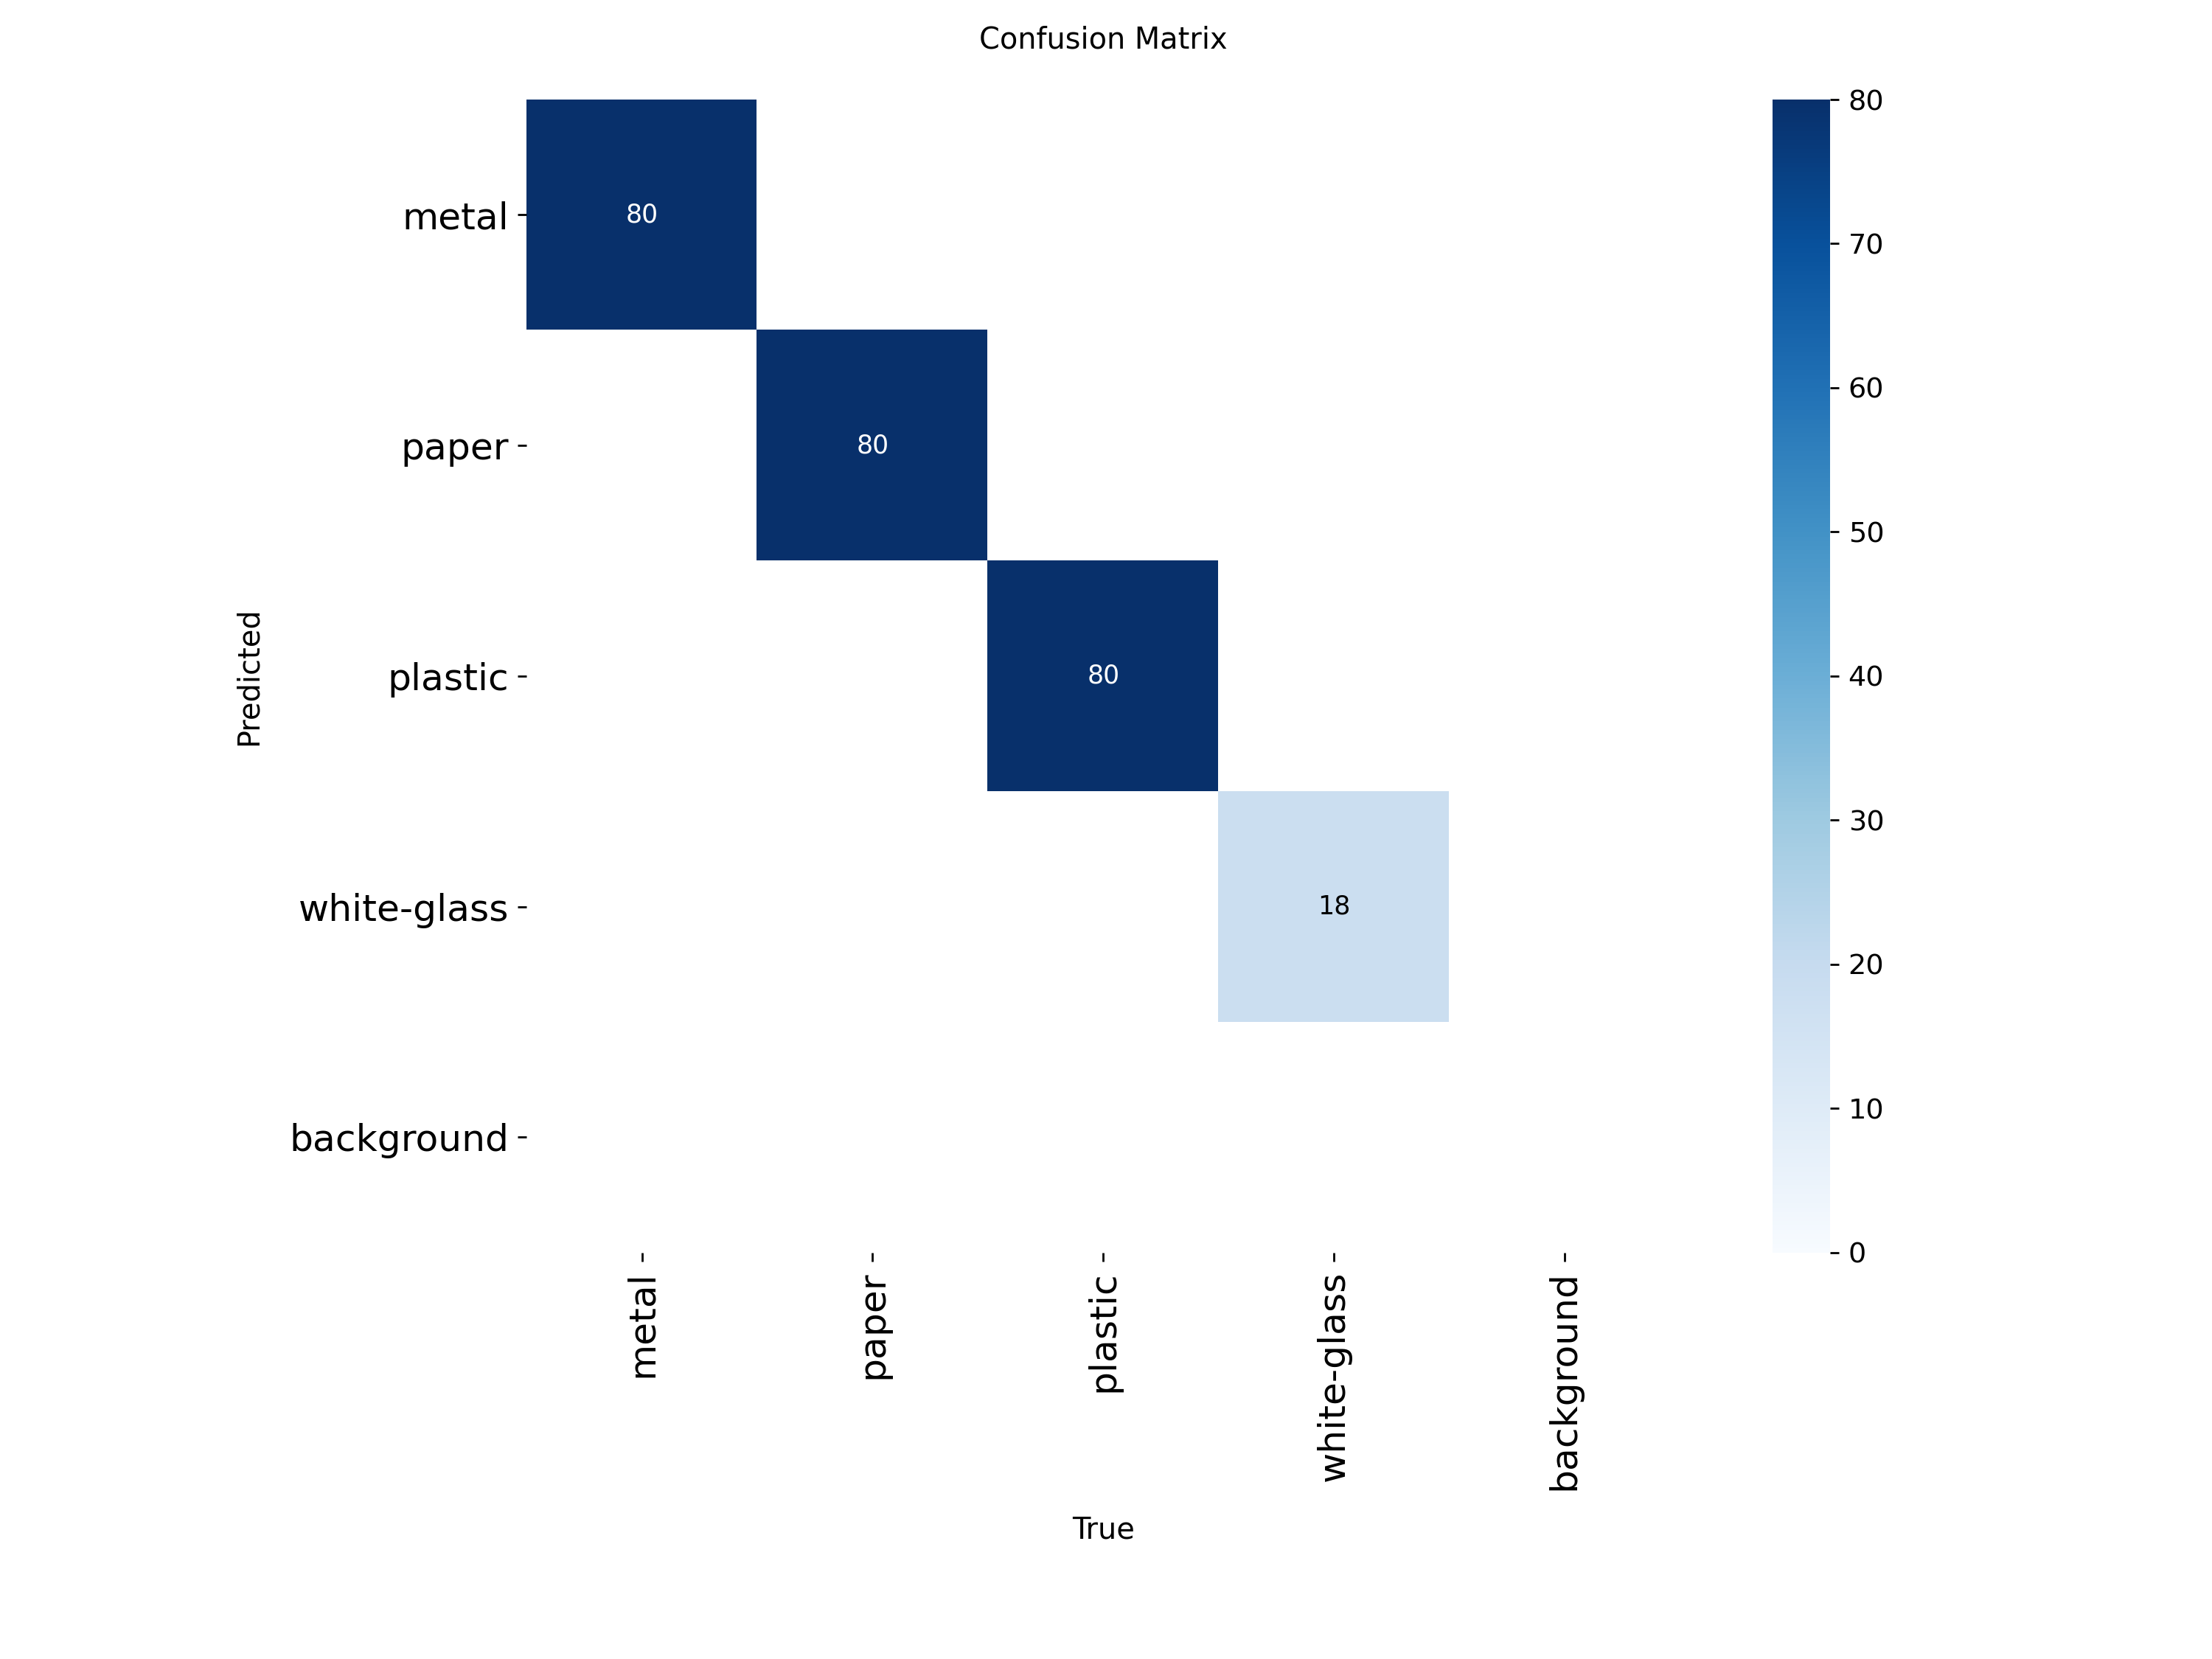


confusion_matrix_normalized.png:


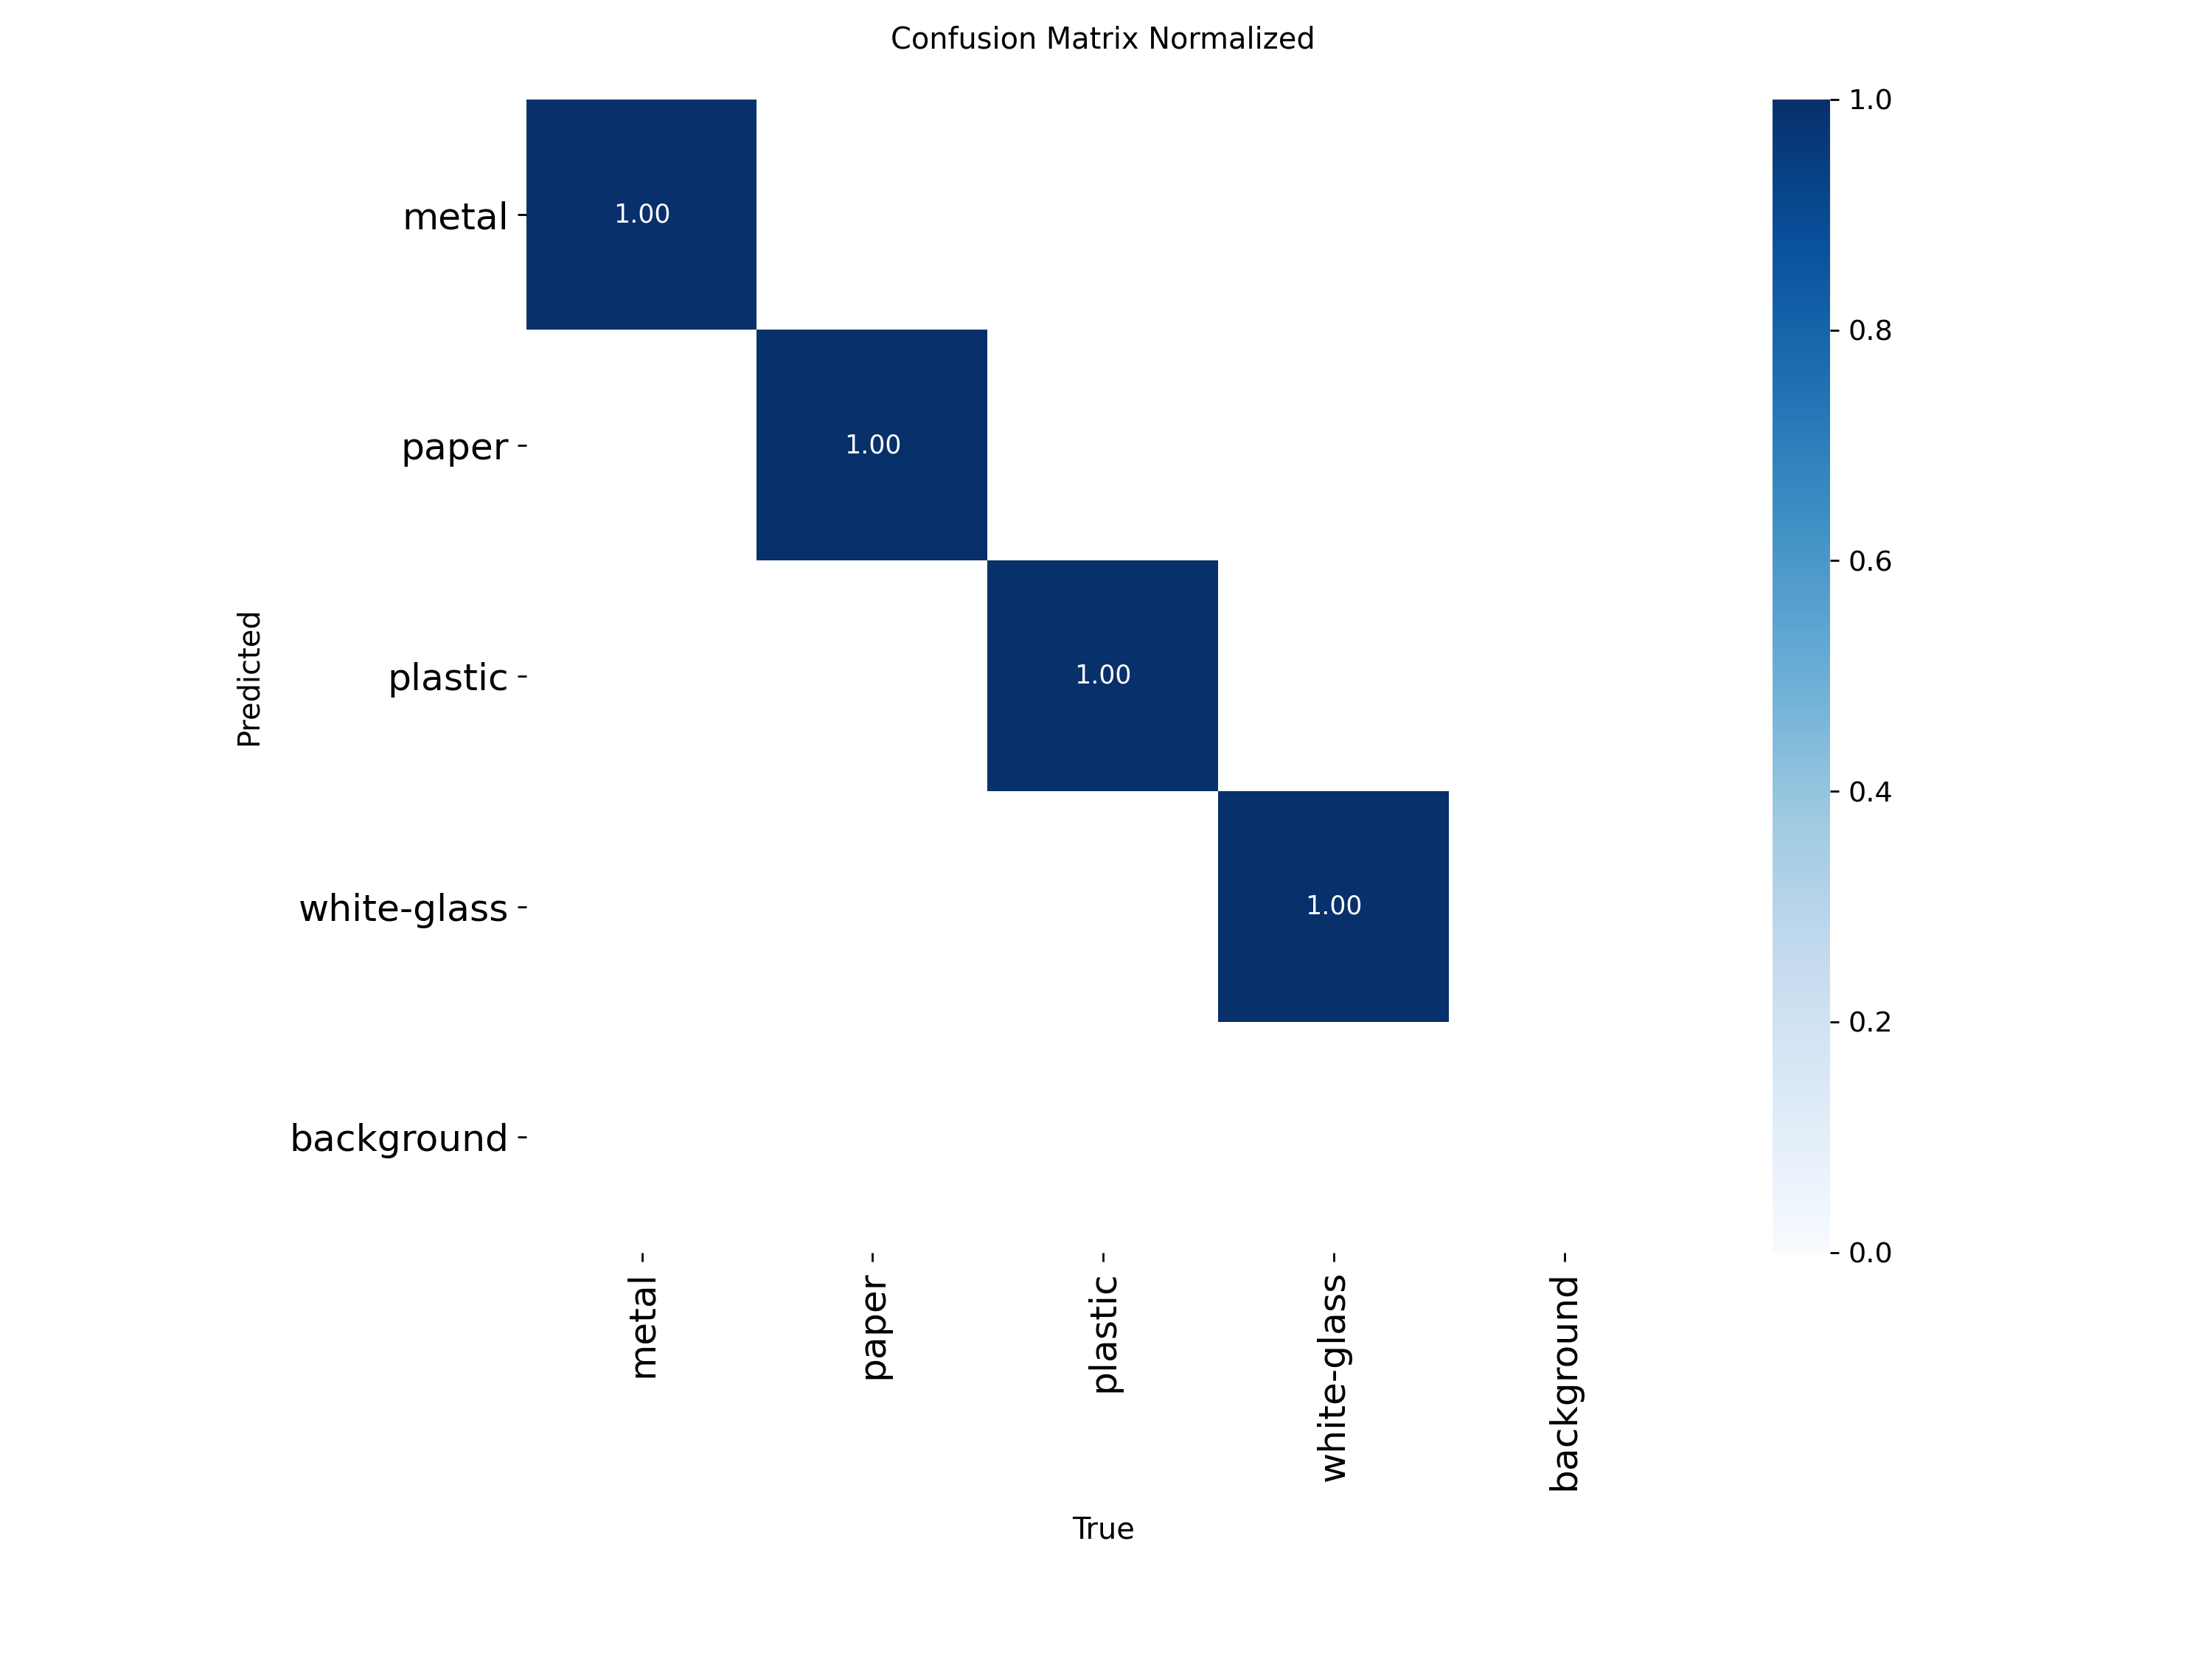


Curvas de treino (results.png):


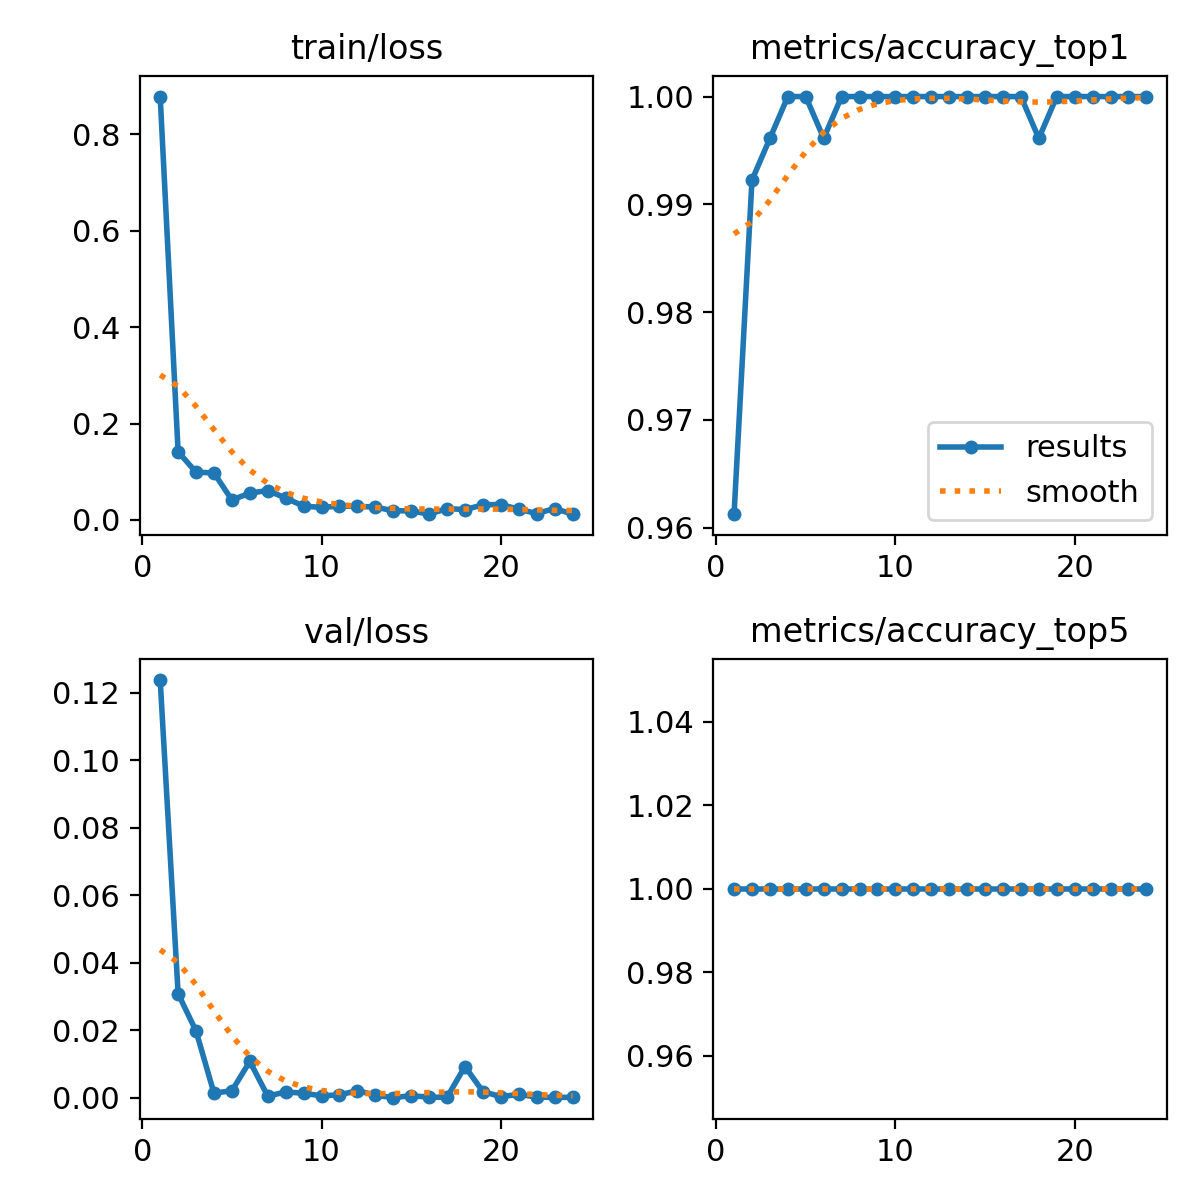

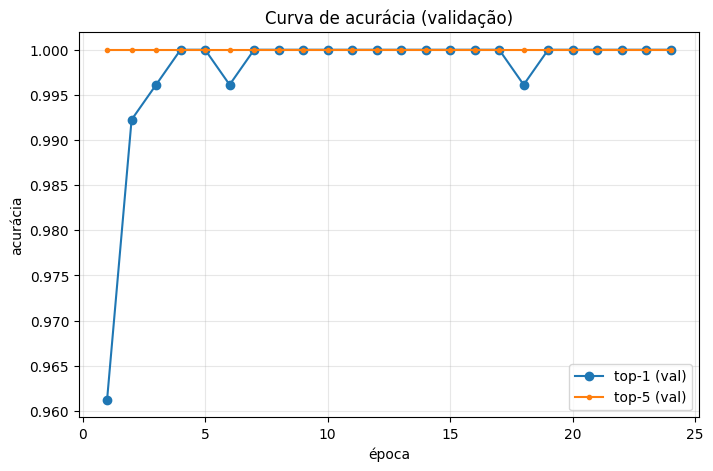


Melhor acurácia top-1: 100.00% (época 4)


In [ ]:
import os, glob
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

BASE = '/content/drive/MyDrive/EcoSort_Modelos'
NOME = 'modelo_camera_v1'

# Acha a pasta do treino (lida com sufixos tipo _v12 se você rodou mais de uma vez)
candidatos = sorted(glob.glob(os.path.join(BASE, NOME + '*')), key=os.path.getmtime)
run_dir = candidatos[-1] if candidatos else os.path.join(BASE, NOME)
print("Pasta do treino:", run_dir)

# 1) Matriz de confusão (normal e normalizada)
for nome in ['confusion_matrix.png', 'confusion_matrix_normalized.png']:
    caminho = os.path.join(run_dir, nome)
    if os.path.exists(caminho):
        print(f"\n{nome}:")
        display(Image(filename=caminho))
    else:
        print(f"(não encontrei {nome})")

# 2) Painel de curvas que o YOLO gera
results_png = os.path.join(run_dir, 'results.png')
if os.path.exists(results_png):
    print("\nCurvas de treino (results.png):")
    display(Image(filename=results_png))

# 3) Curva de acurácia explícita a partir do results.csv
csv = os.path.join(run_dir, 'results.csv')
if os.path.exists(csv):
    df = pd.read_csv(csv)
    df.columns = [c.strip() for c in df.columns]
    col_top1 = next((c for c in df.columns if 'accuracy_top1' in c), None)
    if col_top1:
        plt.figure(figsize=(8, 5))
        plt.plot(df['epoch'], df[col_top1], marker='o', label='top-1 (val)')
        col_top5 = next((c for c in df.columns if 'accuracy_top5' in c), None)
        if col_top5:
            plt.plot(df['epoch'], df[col_top5], marker='.', label='top-5 (val)')
        plt.xlabel('época'); plt.ylabel('acurácia')
        plt.title('Curva de acurácia (validação)')
        plt.grid(True, alpha=0.3); plt.legend(); plt.show()

        melhor = df[col_top1].max()
        ep = int(df.loc[df[col_top1].idxmax(), 'epoch'])
        print(f"\nMelhor acurácia top-1: {melhor*100:.2f}% (época {ep})")
    else:
        print("(results.csv não tem coluna de accuracy_top1)")
else:
    print("(não encontrei results.csv)")